<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


In [3]:
df = pd.read_csv("Titanic.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(df.info())
print("\nSurvival distribution:")
print(df["Survived"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Survival distribution:
Survived
0    549
1    342
Name: count, dtype: int64


In [5]:
df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], inplace=True)


In [6]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


/tmp/ipython-input-761601330.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-761601330.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [7]:
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [8]:
X = df.drop("Survived", axis=1).values
y = df["Survived"].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (891, 7)
y shape: (891,)


In [9]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",   # Information Gain
    random_state=42
)


In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_metrics = []
conf_matrices = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n=========== Fold {fold} ===========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = DecisionTreeClassifier(criterion="entropy", random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    cm = confusion_matrix(y_val, y_pred)

    fold_metrics.append((acc, prec, rec))
    conf_matrices.append(cm)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")



=========== Fold 1 ===========
Accuracy  : 0.8101
Precision : 0.7536
Recall    : 0.7536

=========== Fold 2 ===========
Accuracy  : 0.8146
Precision : 0.7612
Recall    : 0.7500

=========== Fold 3 ===========
Accuracy  : 0.7247
Precision : 0.6267
Recall    : 0.6912

=========== Fold 4 ===========
Accuracy  : 0.7584
Precision : 0.6812
Recall    : 0.6912

=========== Fold 5 ===========
Accuracy  : 0.8034
Precision : 0.7500
Recall    : 0.7391


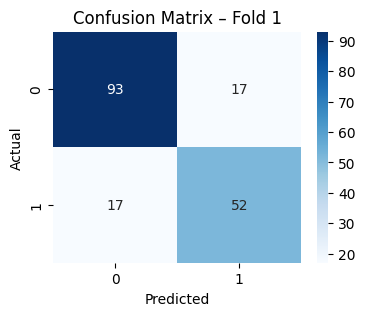

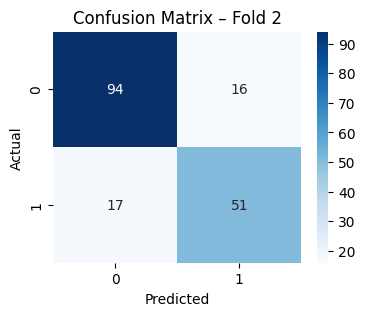

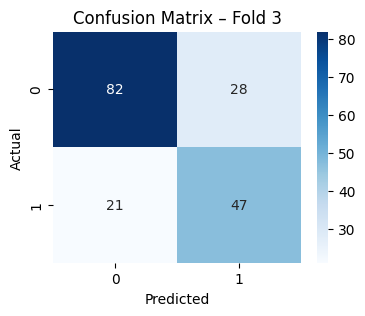

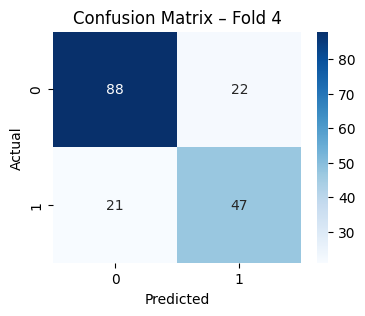

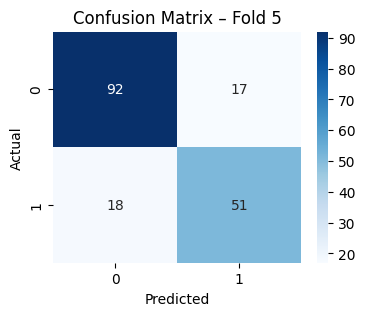

In [11]:
for i, cm in enumerate(conf_matrices, start=1):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – Fold {i}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


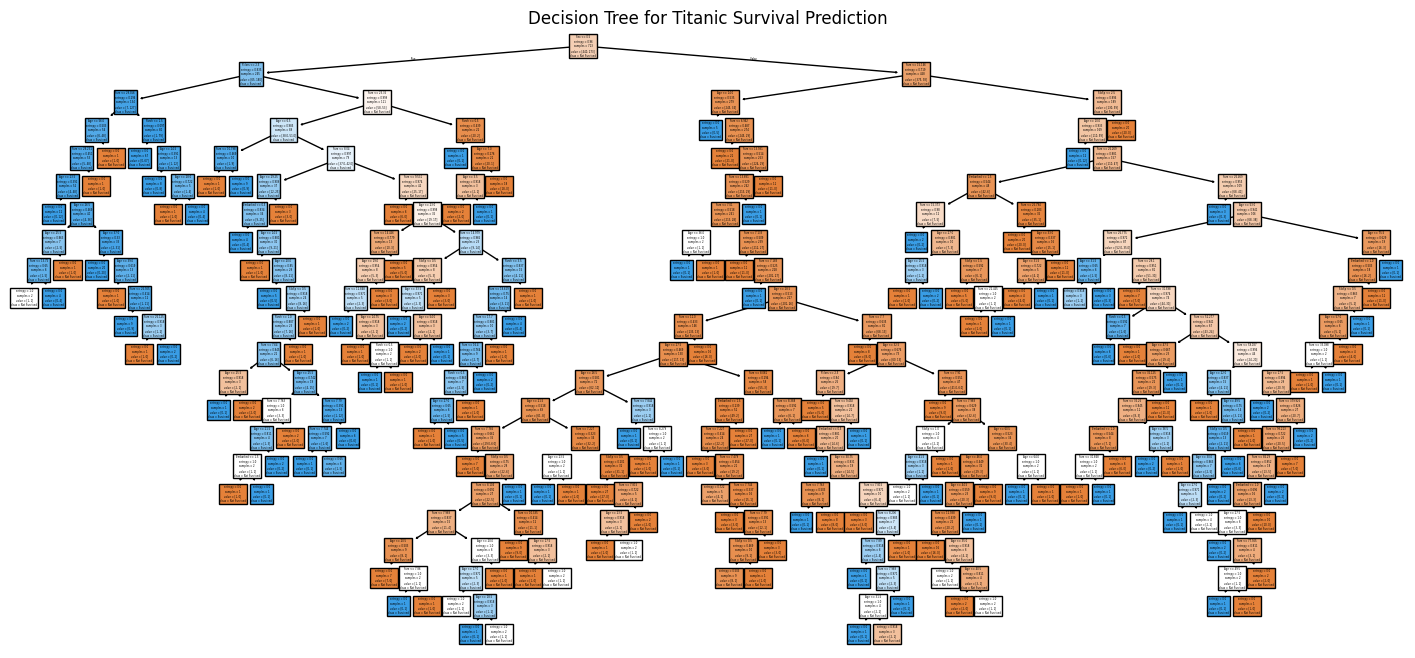

In [12]:
plt.figure(figsize=(18,8))
plot_tree(
    model,
    feature_names=df.drop("Survived", axis=1).columns,
    class_names=["Not Survived", "Survived"],
    filled=True
)
plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()


In [13]:
print("\nFold | Accuracy | Precision | Recall")
print("-----------------------------------")

for i, (acc, prec, rec) in enumerate(fold_metrics, start=1):
    print(f"{i:^4} | {acc:.4f}   | {prec:.4f}    | {rec:.4f}")



Fold | Accuracy | Precision | Recall
-----------------------------------
 1   | 0.8101   | 0.7536    | 0.7536
 2   | 0.8146   | 0.7612    | 0.7500
 3   | 0.7247   | 0.6267    | 0.6912
 4   | 0.7584   | 0.6812    | 0.6912
 5   | 0.8034   | 0.7500    | 0.7391
